In [22]:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # general math functions 

plt.style.use('aps.mplstyle')

T = 300    # period
Omega = 0.5 * np.pi / T   # drive frequency
# define ramping functions
def drive_1(t, Omega):
    if 0 <= t <= T:
        return np.cos(Omega * t)**2
    elif 2*T <= t <= 3*T:
        return np.sin(Omega * (t - 2*T))**2
    else:
        return 0.0
def drive_2(t, Omega):
    if 0 <= t <= 2*T:
        return np.sin(Omega * t)**2
    else:
        return 0.0
def drive_3(t, Omega):
    if T <= t <= 3*T:
        return np.sin(Omega * (t - T))**2
    else:
        return 0.0

# define the ramping functions
times = np.linspace(0, 3*T, 100)
U12_t = [drive_1(t, Omega) for t in times]
U23_t = [drive_2(t, Omega) for t in times]
U31_t = [drive_3(t, Omega) for t in times]

# load the spectrum data
data = np.load('data/e.npz')
E_t = data['E_t']

index = np.linspace(0, len(times)-1, 20, dtype=int)
# load braiding phase
data = np.load('data/bp_1.npz', allow_pickle=True)
braiding_phase_1 = data['braiding_phase']
data = np.load('data/bp_2.npz', allow_pickle=True)
braiding_phase_2 = data['braiding_phase']
data = np.load('data/bp_3.npz', allow_pickle=True)
braiding_phase_3 = data['braiding_phase']

# load loss of fidelity
data = np.load('data/lof.npz', allow_pickle=True)
alpha_values_1 = data['alpha']
T_values_1 = data['T']
loss_of_fidelity = data['loss_of_fidelity']

# load braiding error
data = np.load('data/be.npz', allow_pickle=True)
alpha_values_2 = data['alpha']
T_values_2 = data['T']
braiding_error = abs(data['braiding_error'])

# load loss of fidelity
data = np.load('data/lof_1.npz', allow_pickle=True)
times = data['times']
loss_of_fidelity_1 = data['loss_of_fidelity']
data = np.load('data/lof_2.npz', allow_pickle=True)
loss_of_fidelity_2 = data['loss_of_fidelity']
data = np.load('data/lof_3.npz', allow_pickle=True)
loss_of_fidelity_3 = data['loss_of_fidelity']

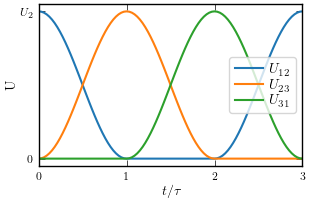

In [27]:
fig, ax = plt.subplots()
ax.plot(times/T, U12_t, label = r"$U_{12}$")
ax.plot(times/T, U23_t, label = r"$U_{23}$")
ax.plot(times/T, U31_t, label = r"$U_{31}$")
ax.set_xmargin(0)
ax.set_xticks(np.linspace(0, 3, 4))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.set_yticks(np.linspace(0, 1, 2))
ax.set_yticklabels(['0', r'$U_2$'])
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"U")
ax.legend(frameon=True)
plt.show()

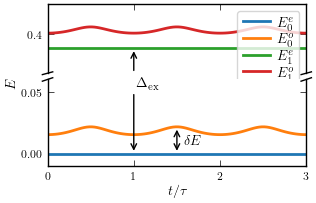

In [24]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 1.25], 'hspace': 0.08}
)

for axis in (ax_top, ax_bottom):
    axis.plot(times/T, E_t[:, 0] - E_t[:, 0], linewidth=2, label=r'$E^e_0$')
    axis.plot(times/T, E_t[:, 2] - E_t[:, 0], linewidth=2, label=r'$E^o_0$')
    axis.plot(times/T, E_t[:, 4] - E_t[:, 0], linewidth=2, label=r'$E^e_1$')
    axis.plot(times/T, E_t[:, 6] - E_t[:, 0], linewidth=2, label=r'$E^o_1$')

ax_bottom.set_ylim(-0.01, 0.06)
ax_top.set_ylim(0.36, 0.43)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Hide the spines between the two subplots.
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_bottom.tick_params(axis='x', top=False, labeltop=False)

# Add diagonal lines to indicate the break in the y-axis.
d = 0.02
kwargs = dict(color='k', clip_on=False, linewidth=1)

ax_top.plot((-d, d), (-d, d),
            transform=ax_top.transAxes, **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, d),
            transform=ax_top.transAxes, **kwargs)

ax_bottom.plot((-d, d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)

fig.text(0.015, 0.5, r'$E$', rotation='vertical', va='center')
ax_bottom.set_xlabel(r'$t/\tau$')
ax_top.legend(frameon=True)
fig.subplots_adjust(left=0.14)

ax_top.set_ylim(0.36, 0.43)
ax_top.set_yticks([0.40])
ax_bottom.set_ylim(-0.01, 0.06)
ax_bottom.set_yticks([0.0, 0.05])
ax_bottom.set_xlim(0, 3)
ax_bottom.set_xticks(np.arange(0, 3.1, 1.0))

# delta E
x_gap = 1.5
i_gap = np.argmin(np.abs(times / T - x_gap))

y0 = E_t[i_gap, 0] - E_t[i_gap, 0]
y2 = E_t[i_gap, 2] - E_t[i_gap, 0]

ax_bottom.annotate(
    '',
    xy=(x_gap, y2),
    xytext=(x_gap, y0),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.text(
    x_gap + 0.08,
    (y0 + y2) / 2,
    r'$\delta E$',
    color='black',
    va='center'
)

# Delta_bulk
x_bulk = 1.0

y1 = E_t[i_gap, 4] - E_t[i_gap, 0]

ax_top.annotate(
    '',
    xy=(x_bulk, y1),
    xytext=(x_bulk, 0.36),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.annotate(
    '',
    xy=(x_bulk, 0.00),
    xytext=(x_bulk, 0.05),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

fig.text(
    0.40, 0.50,
    r'$\Delta_{\mathrm{ex}}$',
    color='black',
    va='center',
    ha='left'
)

plt.savefig('figures/spectrum.pdf', dpi=300, bbox_inches='tight')
plt.show()

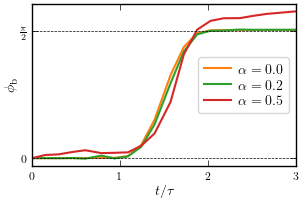

In [25]:
fig, ax = plt.subplots()
ax.plot(times[index]/T, braiding_phase_1[index]/np.pi, color='C1', label=r'$\alpha=0.0$')
ax.plot(times[index]/T, braiding_phase_2[index]/np.pi, color='C2', label=r'$\alpha=0.2$')
ax.plot(times[index]/T, braiding_phase_3[index]/np.pi, color='C3', label=r'$\alpha=0.5$')
ax.plot(times/T, np.ones(len(times))/2, color='k', ls='--', linewidth=0.5)
ax.plot(times/T, np.zeros(len(times)), color='k', ls='--', linewidth=0.5)
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$\phi_{\mathrm{b}}$')
ax.set_xmargin(0)
ax.set_xticks(np.linspace(0, 3, 4))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.set_yticks(np.linspace(0, 0.5, 2))
ax.set_yticklabels(['0', r'$\frac{\pi}{2}$'])
ax.legend(frameon=True)
plt.savefig('Figures/braiding_phase.pdf', dpi=300, bbox_inches='tight')
plt.show()

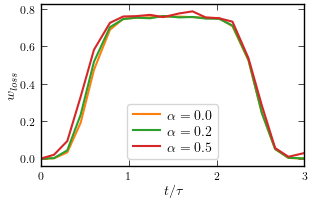

In [17]:
fig, ax = plt.subplots()
ax.plot(times[index]/T, loss_of_fidelity_1[index], color='C1', label=r'$\alpha=0.0$')
ax.plot(times[index]/T, loss_of_fidelity_2[index], color='C2', label=r'$\alpha=0.2$')
ax.plot(times[index]/T, loss_of_fidelity_3[index], color='C3', label=r'$\alpha=0.5$')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$w_{loss}$')
ax.set_xmargin(0)
ax.set_xticks(np.linspace(0, 3, 4))
ax.set_xticklabels(['0', '1', '2', '3'])
ax.legend(frameon=True)
plt.show()

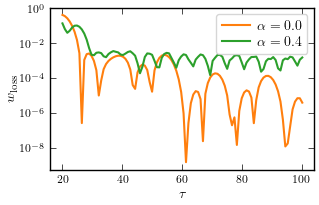

In [26]:
fig, ax = plt.subplots()
ax.semilogy(T_values_1, loss_of_fidelity[0, :], color='C1', label=r'$\alpha=0.0$')
ax.semilogy(T_values_1, loss_of_fidelity[1, :], color='C2', label=r'$\alpha=0.4$')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$w_{\mathrm{loss}}$')
ax.legend(frameon=True)
plt.savefig('figures/loss_of_fidelity.pdf', dpi=300, bbox_inches='tight')
plt.show()

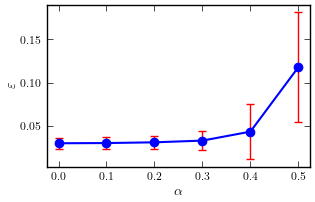

In [28]:
fig, ax = plt.subplots()
ax.errorbar(alpha_values_2, np.mean(braiding_error, axis=1), yerr=np.std(braiding_error, axis=1), fmt='o-', color='blue', ecolor='red', elinewidth=1, capsize=3)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\varepsilon$')
plt.savefig('figures/braiding_error.pdf', dpi=300, bbox_inches='tight')
plt.show()